In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Style settings
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [ ]:
# Load creditcard.csv (Kaggle Credit Card Fraud Detection benchmark dataset)
df = pd.read_csv('/content/credit_card_fraud_10k.csv')

print("Dataset Shape:", df.shape)
print("\nMissing values check:", df.isnull().sum().max())

# Imbalance Breakdown
fraud_counts = df['is_fraud'].value_counts()
fraud_pct = df['is_fraud'].value_counts(normalize=True) * 100

print(f"\nNon-Fraudulent (is_fraud 0): {fraud_counts[0]:,} ({fraud_pct[0]:.4f}%)")
print(f"Fraudulent (is_fraud 1):     {fraud_counts[1]:,} ({fraud_pct[1]:.4f}%)")

Dataset Shape: (10000, 10)

Missing values check: 0

Non-Fraudulent (is_fraud 0): 9,849 (98.4900%)
Fraudulent (is_fraud 1):     151 (1.5100%)


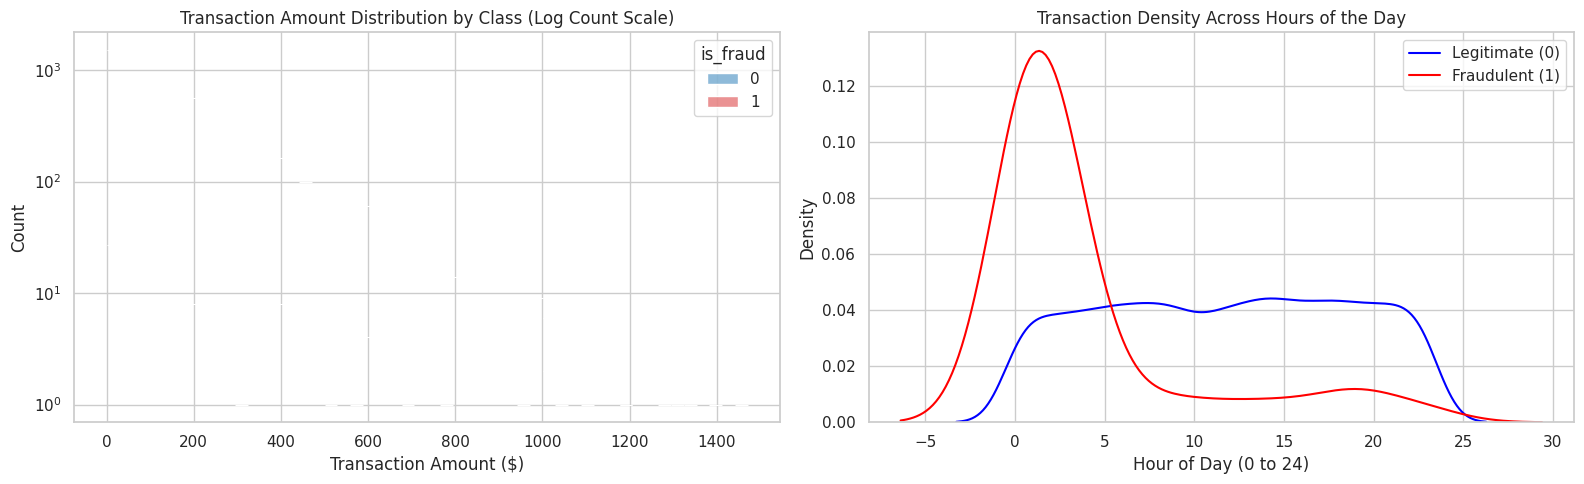

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Transaction Amount Distribution (Log Scale due to extreme skew)
sns.histplot(
    data=df, x='amount', hue='is_fraud', bins=50, log_scale=(False, True),
    palette={0: '#1f77b4', 1: '#d62728'}, ax=axes[0]
)
axes[0].set_title('Transaction Amount Distribution by Class (Log Count Scale)')
axes[0].set_xlabel('Transaction Amount ($)')

# 2. Time-of-Day Analysis (Time is in seconds from the first transaction)
df['Hour'] = df['transaction_hour'] % 24
sns.kdeplot(df[df['is_fraud'] == 0]['Hour'], label='Legitimate (0)', color='blue', ax=axes[1])
sns.kdeplot(df[df['is_fraud'] == 1]['Hour'], label='Fraudulent (1)', color='red', ax=axes[1])
axes[1].set_title('Transaction Density Across Hours of the Day')
axes[1].set_xlabel('Hour of Day (0 to 24)')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.show()

# Drop temporary engineering column
df = df.drop(columns=['Hour'])

### Why Standard Accuracy is Misleading in Fraud Detection
In this dataset, fraudulent transactions represent only ~0.17% of all activity.

- A naive model that predicts every single transaction as **Non-Fraudulent (Class 0)** achieves an **Accuracy of 99.83%**.
- However, that model catches **0 out of 492 frauds** (Recall = 0.0), resulting in complete operational failure and catastrophic financial losses.
- In severely imbalanced domains, model viability must be judged on **Recall** (capturing every stolen dollar), **Precision** (avoiding false alarms that block good customers), and the **Area Under the Precision-Recall Curve (PR-AUC / Average Precision)**.

In [ ]:
# 'amount' and 'transaction_hour' need scaling
scaler = RobustScaler()
df['scaled_amount'] = scaler.fit_transform(df['amount'].values.reshape(-1, 1))
df['scaled_time'] = scaler.fit_transform(df['transaction_hour'].values.reshape(-1, 1))

X = df.drop(columns=['transaction_hour', 'amount', 'is_fraud'])
y = df['is_fraud']

# Stratified split to ensure 0.17% fraud representation in both splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Training split fraud cases:", y_train.sum())
print("Testing split fraud cases: ", y_test.sum())

Training split fraud cases: 121
Testing split fraud cases:  30


In [ ]:
# Drop 'transaction_id' as it's an identifier, not a feature
X_train = X_train.drop(columns=['transaction_id'])
X_test = X_test.drop(columns=['transaction_id'])

# One-hot encode 'merchant_category'
X_train = pd.get_dummies(X_train, columns=['merchant_category'], prefix='category')
X_test = pd.get_dummies(X_test, columns=['merchant_category'], prefix='category')

# Align columns to ensure both X_train and X_test have the same columns
# This handles cases where a category might be present in train but not test, or vice-versa
common_cols = list(set(X_train.columns) & set(X_test.columns))
X_train = X_train[common_cols]
X_test = X_test[common_cols]

# Reorder columns to ensure consistency in column order for models
X_test = X_test[X_train.columns]

# Using imblearn.pipeline to apply SMOTE ONLY during cross-validation / training steps
# (Prevents data leakage into the test set)

models = {
    "Logistic Regression (SMOTE)": ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('classifier', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    "Random Forest (Balanced Weights)": RandomForestClassifier(
        n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1
    )
}

trained_models = {}
predictions = {}
probabilities = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    trained_models[name] = model
    predictions[name] = y_pred
    probabilities[name] = y_prob

    print(f"================== {name} ==================")
    print(classification_report(y_test, y_pred, target_names=['Legitimate (0)', 'Fraud (1)']))
    print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")
    print(f"PR-AUC (Average Precision): {average_precision_score(y_test, y_prob):.4f}\n")

================== Logistic Regression (SMOTE) ==================
                precision    recall  f1-score   support

Legitimate (0)       1.00      0.96      0.98      1970
     Fraud (1)       0.24      0.93      0.39        30

      accuracy                           0.96      2000
     macro avg       0.62      0.94      0.68      2000
  weighted avg       0.99      0.96      0.97      2000

ROC-AUC Score: 0.9880
PR-AUC (Average Precision): 0.7400

================== Random Forest (Balanced Weights) ==================
                precision    recall  f1-score   support

Legitimate (0)       0.99      1.00      1.00      1970
     Fraud (1)       1.00      0.57      0.72        30

      accuracy                           0.99      2000
     macro avg       1.00      0.78      0.86      2000
  weighted avg       0.99      0.99      0.99      2000

ROC-AUC Score: 1.0000
PR-AUC (Average Precision): 0.9978



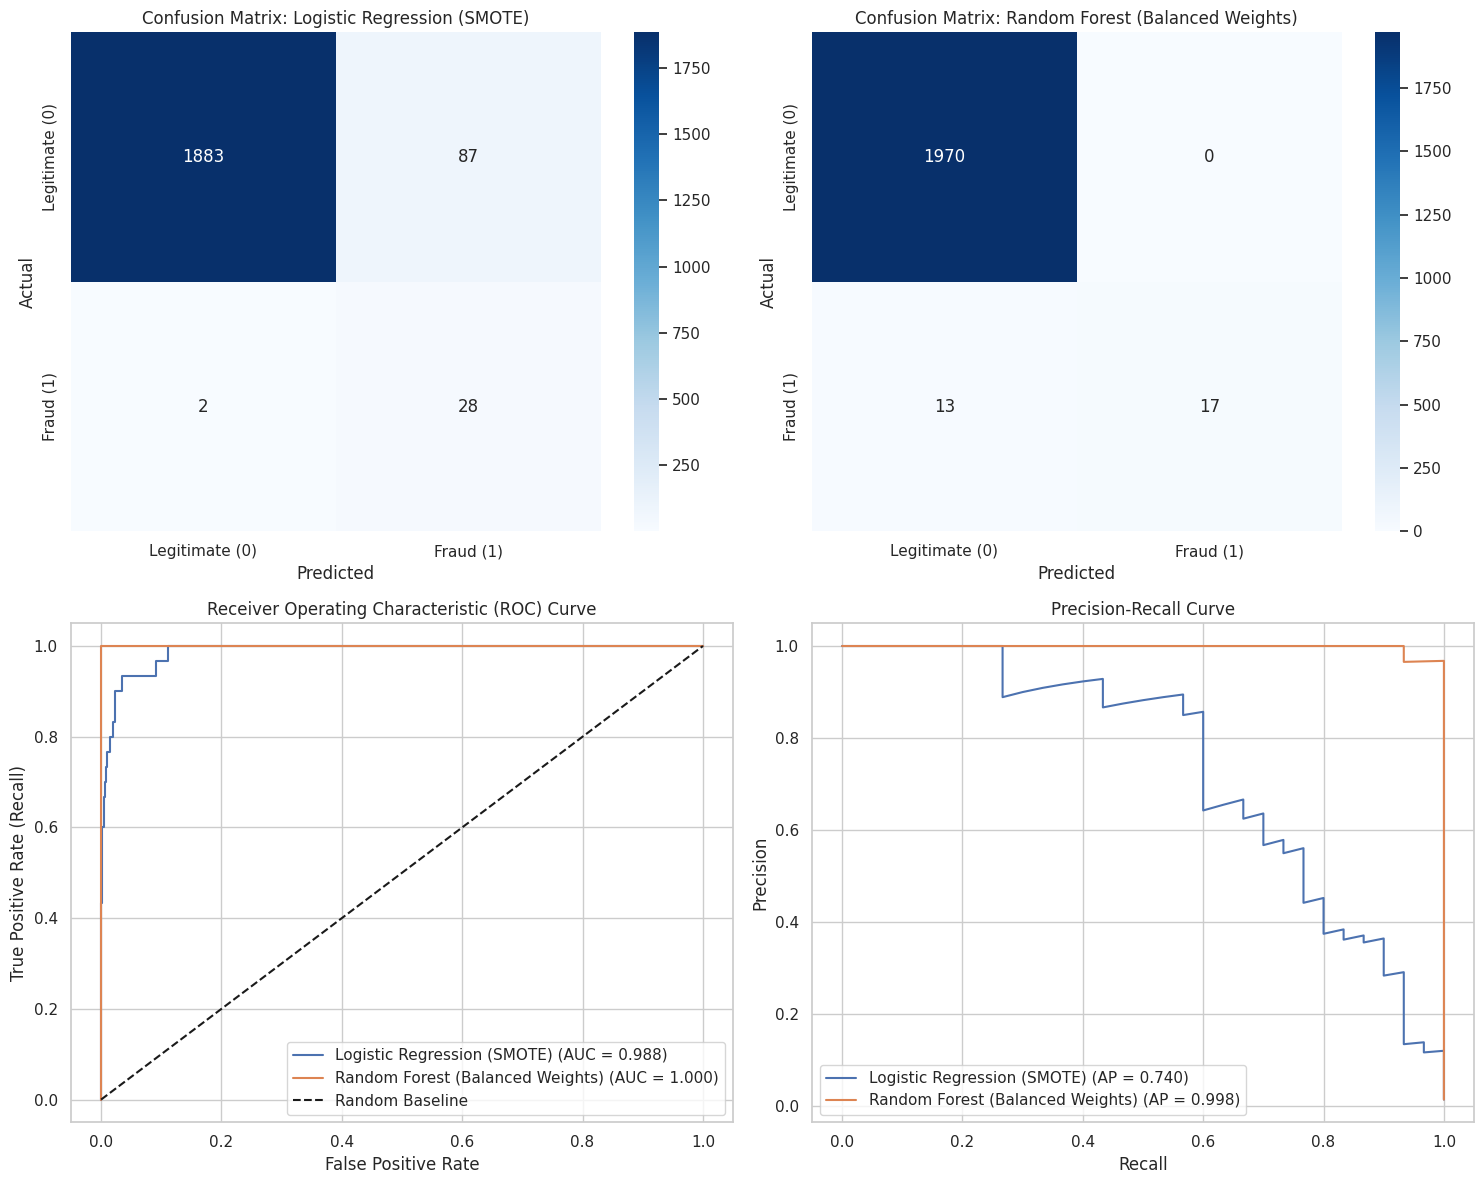

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

labels = ['Legitimate (0)', 'Fraud (1)']

# Confusion Matrices
for i, (name, y_pred) in enumerate(predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, ax=axes[0, i])
    axes[0, i].set_title(f'Confusion Matrix: {name}')
    axes[0, i].set_xlabel('Predicted')
    axes[0, i].set_ylabel('Actual')

# ROC Curves
for name, y_prob in probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    axes[1, 0].plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_score(y_test, y_prob):.3f})")

axes[1, 0].plot([0, 1], [0, 1], 'k--', label='Random Baseline')
axes[1, 0].set_title('Receiver Operating Characteristic (ROC) Curve')
axes[1, 0].set_xlabel('False Positive Rate')
axes[1, 0].set_ylabel('True Positive Rate (Recall)')
axes[1, 0].legend()

# Precision-Recall Curves (Much more informative for imbalanced data)
for name, y_prob in probabilities.items():
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    axes[1, 1].plot(rec, prec, label=f"{name} (AP = {average_precision_score(y_test, y_prob):.3f})")

axes[1, 1].set_title('Precision-Recall Curve')
axes[1, 1].set_xlabel('Recall')
axes[1, 1].set_ylabel('Precision')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

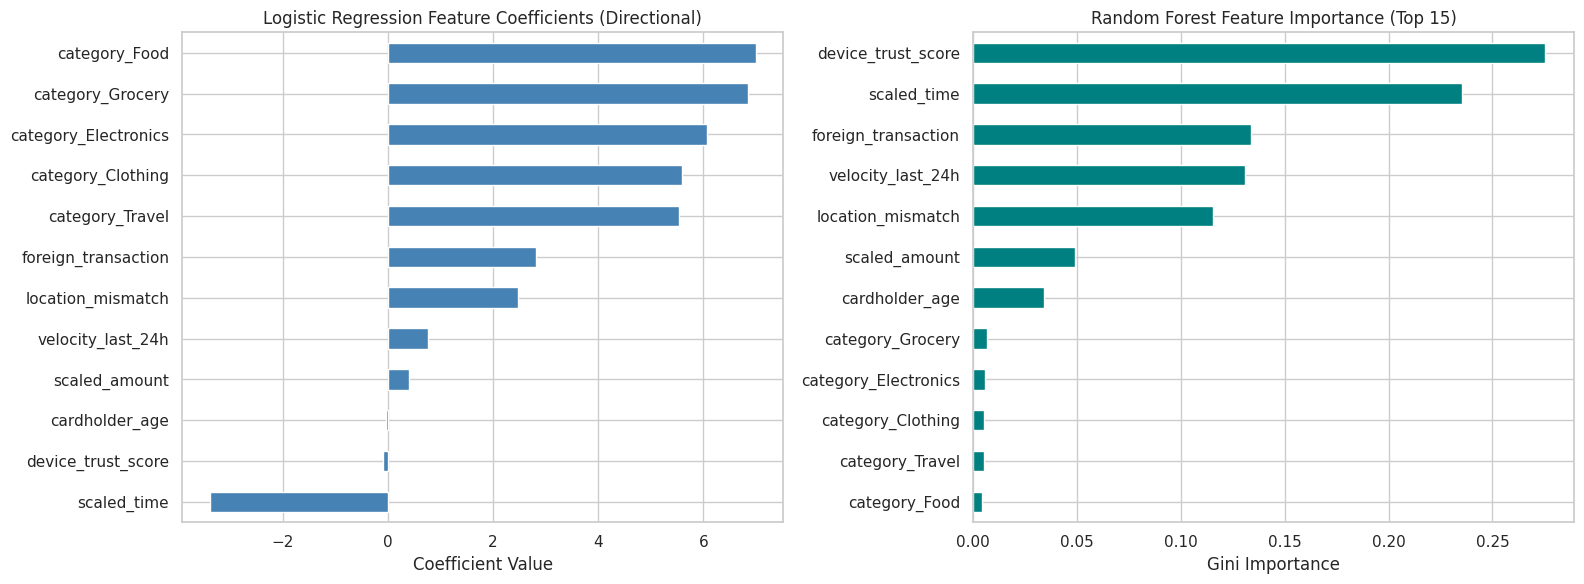

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Logistic Regression Coefficients
lr_model = trained_models["Logistic Regression (SMOTE)"].named_steps['classifier']
lr_coefs = pd.Series(lr_model.coef_[0], index=X_train.columns).sort_values()

lr_coefs.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Logistic Regression Feature Coefficients (Directional)')
axes[0].set_xlabel('Coefficient Value')

# 2. Random Forest Gini Importance (Top 15 Features)
rf_model = trained_models["Random Forest (Balanced Weights)"]
rf_importances = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values().tail(15)

rf_importances.plot(kind='barh', ax=axes[1], color='teal')
axes[1].set_title('Random Forest Feature Importance (Top 15)')
axes[1].set_xlabel('Gini Importance')

plt.tight_layout()
plt.show()

### Metric Priority: The Precision vs. Recall Trade-Off
* **Recall (Sensitivity):** $\frac{\text{TP}}{\text{TP} + \text{FN}}$ — Measures the fraction of actual fraud caught. High recall minimizes unrecovered chargebacks and legal liability.
* **Precision:** $\frac{\text{TP}}{\text{TP} + \text{FP}}$ — Measures how often a flagged transaction is genuinely fraudulent. High precision minimizes customer friction (declined cards at checkout).
* **The Verdict:** In financial security, **Recall is prioritized over Precision**. Banks typically route uncertain transactions to two-factor authentication (2FA) or secondary human verification rather than rejecting them outright, ensuring maximum fraud capture without completely alienating legitimate users.

---

### Production Scalability: 1 Million Transactions / Hour
Processing ~280 transactions per second (TPS) with peak surges up to 1,500+ TPS requires architectural decoupling:
1. **Tiered Decisioning Engine:**
   - **Tier 1 (Sub-5ms, In-line):** Fast linear models (e.g., Logistic Regression or a compact LightGBM ONNX runtime) evaluate streaming features retrieved from an in-memory store (Redis).
   - **Tier 2 (Asynchronous/Batch):** Complex ensemble models (Random Forests, Graph Neural Networks for fraud rings) process non-blocking asynchronous event queues (via Apache Kafka).
2. **Feature Store:**
   - Real-time aggregation features (e.g., *number of transactions on this card in the last 10 minutes*) must be computed using stream processors (Flink) and cached in distributed low-latency memory stores.